In [32]:
import os, re, glob, datetime
import numpy as np, pandas as pd
import h5py, torch, torch.nn as nn
import matplotlib.pyplot as plt

RESULTS_DIR = "/grid/koo/home/pmantill/projects/VBI/VAE_gmm/explicit_M/results"
SEAM_DIR    = "/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq"
OUT_DIR     = "/grid/koo/home/pmantill/projects/VBI/VAE_gmm/BIC_benchmark"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [33]:
# ----- model definition (verbatim from warmup_vae_farthest/mstep.ipynb, needed to load state_dict) -----
class VAE_GMM(nn.Module):
    """VAE over the foreground f=decoder(z); shared bg Gaussian N(mu_b,sigma_b^2) added
    before the reconstruction; GMM(K) prior on z with a Dirichlet(alpha) posterior on pi."""
    def __init__(self, D, J, K, alpha0, hidden, var_data):
        super().__init__()
        self.D, self.J, self.K, self.alpha0 = D, J, K, alpha0
        self.enc = nn.Sequential(nn.Linear(D, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU())
        self.enc_mu = nn.Linear(hidden, J)
        self.enc_lv = nn.Linear(hidden, J)
        self.dec = nn.Sequential(nn.Linear(J, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, D))
        self.mu_b     = nn.Parameter(torch.zeros(D))
        self.log_var_b = nn.Parameter(torch.tensor(float(np.log(var_data.mean()))))
        self.mu_c     = nn.Parameter(0.1 * torch.randn(K, J))
        self.log_var_c = nn.Parameter(torch.zeros(K, J))
        self.register_buffer("alpha_", torch.full((K,), alpha0 + 1.0))

    @property
    def alpha(self):
        return self.alpha_

    def encode(self, x):
        h = self.enc(x)
        return self.enc_mu(h), self.enc_lv(h)

    @torch.no_grad()
    def elbo_and_gamma(self, x):
        """Per-sample ELBO at z=mu_z (deterministic, no reparam noise) and the model's
        responsibilities gamma -- exactly the training E-step (VB posterior over the K components)."""
        mu_z, lv_z = self.encode(x)                                # (B,J)
        recon = self.dec(mu_z) + self.mu_b                         # z = mu_z (posterior mean)
        log_p_x = -0.5 * (np.log(2*np.pi) + self.log_var_b
                          + (x - recon)**2 * torch.exp(-self.log_var_b)).sum(-1)   # (B,)
        lv_z_e, mu_z_e = lv_z[:, None, :], mu_z[:, None, :]        # (B,1,J)
        lv_c, mu_c     = self.log_var_c[None], self.mu_c[None]     # (1,K,J)
        KL_k = 0.5 * (lv_c - lv_z_e
                      + (torch.exp(lv_z_e) + (mu_z_e - mu_c)**2) * torch.exp(-lv_c)
                      - 1.0).sum(-1)                               # (B,K)
        alpha   = self.alpha
        Elog_pi = torch.digamma(alpha) - torch.digamma(alpha.sum())
        log_un  = Elog_pi[None] - KL_k
        log_gamma = log_un - torch.logsumexp(log_un, 1, keepdim=True)
        gamma = log_gamma.exp()                                    # (B,K) responsibilities tau
        klz_term = -(gamma * KL_k).sum(-1)
        cat_term = (gamma * (Elog_pi[None] - log_gamma)).sum(-1)
        elbo_n   = log_p_x + klz_term + cat_term                  # (B,)
        return elbo_n, gamma
print("VAE_GMM defined")

VAE_GMM defined


In [34]:
# ----- select ALL base-model fits, matched by (sequence, J) -----
# base model = plain output of the two named notebooks: ...mstep.ff.seed*  or  ...mstep.rfdmu.seed*
# (same VAE_GMM architecture, raw ism_centered inputs -> BIC comparable within a seq; compare within a J).
BASE_PAT = re.compile(r"\.mstep\.(ff|rfdmu)\.seed\d+\.pt$")

def init_label(fname):
    return "farthest" if ".mstep.ff." in fname else "mstep"

# gather every base checkpoint with its (peak, J) so we can see BIC/ICL across all matched configs
recs = []
for f in glob.glob(f"{RESULTS_DIR}/*.pt"):
    if not BASE_PAT.search(os.path.basename(f)):
        continue
    hp = torch.load(f, map_location="cpu", weights_only=False)["hp"]
    recs.append((hp["peak"], hp["J"], os.path.getmtime(f), f))

# order by (peak, J, mtime) so groups read cleanly; keep them all
recs.sort(key=lambda r: (r[0], r[1], -r[2]))
selected = [(peak, f) for peak, J, mt, f in recs]

# print inventory grouped by (peak, J)
from itertools import groupby
print(f"{len(selected)} base configs across {len(set(r[0] for r in recs))} sequences\n")
for peak, grp in groupby(recs, key=lambda r: r[0]):
    grp = list(grp)
    print(f"{peak}  ({len(grp)} configs)")
    for J, jg in groupby(grp, key=lambda r: r[1]):
        jg = list(jg)
        print(f"  J{J}: {len(jg)}")
        for _, _, mt, f in jg:
            ts = datetime.datetime.fromtimestamp(mt).strftime("%m-%d %H:%M")
            print(f"      {ts}  [{init_label(os.path.basename(f)):8s}]  {os.path.basename(f)}")

17 base configs across 3 sequences

peak26256  (3 configs)
  J4: 1
      08-02 15:17  [mstep   ]  peak26256.100k.J4.K200.h512.a0.001.warm30.mstep.rfdmu.seed9.pt
  J8: 2
      07-28 15:06  [farthest]  peak26256.100k.J8.K200.h512.a0.001.warm30.mstep.ff.seed9.pt
      07-28 15:04  [mstep   ]  peak26256.100k.J8.K200.h512.a0.001.warm30.mstep.rfdmu.seed9.pt
peak27535_Reversed  (12 configs)
  J2: 1
      07-22 15:50  [mstep   ]  peak27535_Reversed.100k.J2.K500.h512.a0.001.warm30.mstep.rfdmu.seed9.pt
  J4: 4
      07-22 16:30  [farthest]  peak27535_Reversed.100k.J4.K200.h512.a0.001.warm30.mstep.ff.seed9.pt
      07-22 15:42  [mstep   ]  peak27535_Reversed.100k.J4.K500.h512.a0.001.warm30.mstep.rfdmu.seed9.pt
      07-22 15:34  [mstep   ]  peak27535_Reversed.100k.J4.K200.h512.a0.001.warm30.mstep.rfdmu.seed9.pt
      07-22 15:05  [mstep   ]  peak27535_Reversed.100k.J4.K200.h256.a0.001.warm30.mstep.rfdmu.seed9.pt
  J8: 7
      08-03 11:16  [farthest]  peak27535_Reversed.100k.J8.K200.h512.a0.001.wa

In [35]:
# ----- data loader: the ELBO must be evaluated on the same ISM maps the model was fit on -----
_data_cache = {}
def get_data(peak, lib):
    key = (peak, lib)
    if key not in _data_cache:
        suffix = {"100k": "", "200k": "_200k"}[lib]
        with h5py.File(f"{SEAM_DIR}/ism{suffix}/{peak}.h5") as f:
            attr = f["ism_centered"][:]                      # (N,200,4) mean-centered ISM
        X = attr.reshape(attr.shape[0], -1).astype(np.float32)  # (N, 4L)
        _data_cache[key] = torch.from_numpy(X).to(device)
    return _data_cache[key]

In [36]:
# ----- score every selected checkpoint: BIC / ICL from the model's ELBO + normal responsibilities -----
# ONE likelihood (ELBO) and ONE set of responsibilities (the E-step gamma). A vs B differ only in p:
#   A (full)      -> p_full = all trainable weights + surviving-GMM params
#   B (mixture)   -> p_gmm  = surviving-GMM params only (VAE treated as a fixed feature extractor)
def _entropy(gamma):  # EN contribution: -sum tau ln tau over a batch, 0 ln 0 = 0 (only surviving comps carry mass)
    return float((-torch.where(gamma > 0, gamma * torch.log(gamma),
                               torch.zeros_like(gamma))).sum())

def score_checkpoint(path):
    ck = torch.load(path, map_location=device, weights_only=False)
    hp = ck["hp"]
    peak, lib, J, K, hidden, a0 = hp["peak"], hp["lib"], hp["J"], hp["K"], hp["hidden"], hp["alpha0"]
    warm, seed = hp.get("warmup_epochs"), hp.get("seed")
    X_t = get_data(peak, lib)
    N, D = X_t.shape

    model = VAE_GMM(D, J, K, a0, hidden, np.ones(D, np.float32)).to(device)
    model.load_state_dict(ck["state_dict"])   # overwrites the dummy var_data init
    model.eval()

    logL = EN = 0.0               # logL = ELBO;  EN from the model's responsibilities gamma
    for i in range(0, N, 4096):
        e, g = model.elbo_and_gamma(X_t[i:i+4096])
        logL += float(e.sum()); EN += _entropy(g)

    with torch.no_grad():
        alpha = model.alpha
        E_pi  = (alpha / alpha.sum()).cpu().numpy()
    K_alive = int((E_pi > 1.0 / N).sum())     # surviving components

    vae_params = sum(p.numel() for p in [*model.enc.parameters(), *model.enc_mu.parameters(),
                                         *model.enc_lv.parameters(), *model.dec.parameters(),
                                         model.mu_b, model.log_var_b])
    gmm_params = K_alive * (2 * J) + max(K_alive - 1, 0)   # surviving means+vars + mixture weights
    p_full = vae_params + gmm_params
    p_gmm  = gmm_params

    init = init_label(os.path.basename(path))
    label = f"{init}.K{K}.h{hidden}.a{a0:g}.w{warm}.s{seed}"       # unambiguous per config
    lnN = np.log(N)
    return dict(peak=peak, model=label, init=init, lib=lib, J=J, K=K, hidden=hidden,
                alpha0=a0, warm=warm, seed=seed, n=N, K_alive=K_alive, logL=logL, EN=EN,
                p_full=p_full, BIC_full=-2*logL + p_full*lnN, ICL_full=-2*logL + p_full*lnN + 2*EN,
                p_gmm=p_gmm,   BIC_gmm =-2*logL + p_gmm*lnN,  ICL_gmm =-2*logL + p_gmm*lnN + 2*EN,
                file=os.path.basename(path))

rows = []
for peak, path in selected:
    r = score_checkpoint(path)
    rows.append(r)
    print(f"{r['peak']:20s} J{r['J']} {r['model']:28s} K_alive={r['K_alive']:3d}  "
          f"A BIC={r['BIC_full']:.4e}   B BIC={r['BIC_gmm']:.4e}")

peak26256            J4 mstep.K200.h512.a0.001.w30.s9 K_alive=119  A BIC=-2.1087e+08   B BIC=-2.2645e+08
peak26256            J8 farthest.K200.h512.a0.001.w30.s9 K_alive=  3  A BIC=-2.2297e+08   B BIC=-2.3862e+08
peak26256            J8 mstep.K200.h512.a0.001.w30.s9 K_alive=  3  A BIC=-2.2329e+08   B BIC=-2.3894e+08
peak27535_Reversed   J2 mstep.K500.h512.a0.001.w30.s9 K_alive=140  A BIC=-2.1066e+08   B BIC=-2.2621e+08
peak27535_Reversed   J4 farthest.K200.h512.a0.001.w30.s9 K_alive= 32  A BIC=-2.1977e+08   B BIC=-2.3535e+08
peak27535_Reversed   J4 mstep.K500.h512.a0.001.w30.s9 K_alive= 48  A BIC=-2.2190e+08   B BIC=-2.3748e+08
peak27535_Reversed   J4 mstep.K200.h512.a0.001.w30.s9 K_alive= 32  A BIC=-2.2166e+08   B BIC=-2.3724e+08
peak27535_Reversed   J4 mstep.K200.h256.a0.001.w30.s9 K_alive= 87  A BIC=-2.3058e+08   B BIC=-2.3688e+08
peak27535_Reversed   J8 farthest.K200.h512.a0.001.w10.s9 K_alive= 13  A BIC=-2.3369e+08   B BIC=-2.4934e+08
peak27535_Reversed   J8 farthest.K200.h512.a0.

In [37]:
# ----- results table (grouped by seq; lower BIC / ICL is better) -----
cols = ["peak", "model", "init", "lib", "J", "K", "hidden", "alpha0", "warm", "seed", "n", "K_alive",
        "logL", "EN", "p_full", "BIC_full", "ICL_full", "p_gmm", "BIC_gmm", "ICL_gmm", "file"]
df = pd.DataFrame(rows)[cols].sort_values(["peak", "BIC_full"]).reset_index(drop=True)
csv_path = f"{OUT_DIR}/bic_icl_benchmark.csv"
df.to_csv(csv_path, index=False)
print("saved ->", csv_path)
# bold the best (min) within each seq (same data space / same logL for every model -> comparable)
def _hi(col):
    best = df.groupby("peak")[col].transform("min")
    return np.where(df[col] == best, "font-weight:bold;background:#d8f0d8", "")
sty = df.style
for c in ["BIC_full", "ICL_full", "BIC_gmm", "ICL_gmm"]:
    sty = sty.apply(lambda s, c=c: _hi(c), subset=[c])
sty

saved -> /grid/koo/home/pmantill/projects/VBI/VAE_gmm/BIC_benchmark/bic_icl_benchmark.csv


,peak,model,init,lib,J,K,hidden,alpha0,warm,seed,n,K_alive,logL,EN,p_full,BIC_full,ICL_full,p_gmm,BIC_gmm,ICL_gmm,file
0,peak26256,mstep.K200.h512.a0.001.w30.s9,mstep,100k,8,200,512,0.001000,30,9,100000,3,119469948.750000,18448.327271,1359491,-223288178.946702,-223251282.292161,50,-238939321.853727,-238902425.199186,peak26256.100k.J8.K200.h512.a0.001.warm30.mstep.rfdmu.seed9.pt
1,peak26256,farthest.K200.h512.a0.001.w30.s9,farthest,100k,8,200,512,0.001000,30,9,100000,3,119309904.125000,24429.223206,1359491,-222968089.696702,-222919231.250291,50,-238619232.603727,-238570374.157316,peak26256.100k.J8.K200.h512.a0.001.warm30.mstep.ff.seed9.pt
2,peak26256,mstep.K200.h512.a0.001.w30.s9,mstep,100k,4,200,512,0.001000,30,9,100000,119,113231067.500000,222295.983398,1354359,-210869500.780188,-210424908.813392,1070,-226449816.169752,-226005224.202956,peak26256.100k.J4.K200.h512.a0.001.warm30.mstep.rfdmu.seed9.pt
3,peak27535_Reversed,mstep.K200.h512.a0.001.w30.s15,mstep,100k,8,200,512,0.001000,30,15,100000,1,125877873.000000,0.000000,1359457,-236104418.886168,-236104418.886168,16,-251755561.793193,-251755561.793193,peak27535_Reversed.100k.J8.K200.h512.a0.001.warm30.mstep.rfdmu.seed15.pt
4,peak27535_Reversed,mstep.K200.h512.a0.001.w30.s12,mstep,100k,8,200,512,0.001000,30,12,100000,3,125471963.750000,16480.231201,1359491,-235292208.946702,-235259248.484300,50,-250943351.853727,-250910391.391324,peak27535_Reversed.100k.J8.K200.h512.a0.001.warm30.mstep.rfdmu.seed12.pt
5,peak27535_Reversed,mstep.K200.h512.a0.001.w30.s9,mstep,100k,8,200,512,0.001000,30,9,100000,5,124959424.000000,27279.745178,1359525,-234266738.007236,-234212178.516880,84,-249917880.914261,-249863321.423905,peak27535_Reversed.100k.J8.K200.h512.a0.001.warm30.mstep.rfdmu.seed9.pt
6,peak27535_Reversed,farthest.K200.h512.a0.01.w10.s9,farthest,100k,8,200,512,0.010000,10,9,100000,13,124686604.250000,40937.397827,1359661,-233719532.749373,-233637657.953719,220,-249370675.656398,-249288800.860743,peak27535_Reversed.100k.J8.K200.h512.a0.01.warm10.mstep.ff.seed9.pt
7,peak27535_Reversed,farthest.K200.h512.a0.001.w10.s9,farthest,100k,8,200,512,0.001000,10,9,100000,13,124672117.750000,39695.059143,1359661,-233690559.749373,-233611169.631087,220,-249341702.656398,-249262312.538112,peak27535_Reversed.100k.J8.K200.h512.a0.001.warm10.mstep.ff.seed9.pt
8,peak27535_Reversed,farthest.K200.h512.a0.001.w30.s9,farthest,100k,8,200,512,0.001000,30,9,100000,3,124413309.000000,13647.524658,1359491,-233174899.446702,-233147604.397386,50,-248826042.353727,-248798747.304410,peak27535_Reversed.100k.J8.K200.h512.a0.001.warm30.mstep.ff.seed9.pt
9,peak27535_Reversed,mstep.K500.h512.a0.001.w30.s13,mstep,100k,8,500,512,0.001000,30,13,100000,2,124195991.500000,6483.361946,1359474,-232740460.166435,-232727493.442543,33,-248391603.073460,-248378636.349567,peak27535_Reversed.100k.J8.K500.h512.a0.001.warm30.mstep.rfdmu.seed13.pt


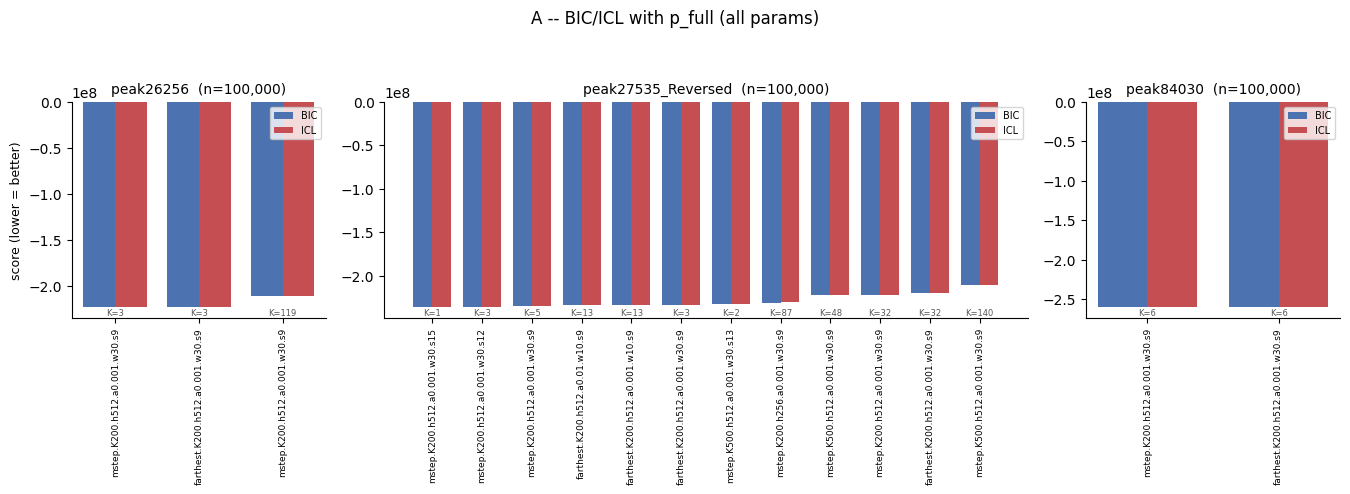

In [38]:
# ----- BIC / ICL per config, one panel per sequence (seqs side by side) -----
# logL lives in data space R^D (same for every model), so all configs within a seq are comparable.
def plot_bic(bic, icl, ttl, fname):
    peaks = sorted(df["peak"].unique())
    widths = [max(3.0, 0.55*len(df[df["peak"] == p]) + 1.0) for p in peaks]   # size to config count
    fig, axes = plt.subplots(1, len(peaks), figsize=(sum(widths), 4.8),
                             squeeze=False, gridspec_kw={"width_ratios": widths})
    for ci, peak in enumerate(peaks):
        d = df[df["peak"] == peak].sort_values(bic).reset_index(drop=True)
        a = axes[0][ci]
        x = np.arange(len(d), dtype=float); w = 0.38
        a.bar(x - w/2, d[bic], w, label="BIC", color="#4C72B0")
        a.bar(x + w/2, d[icl], w, label="ICL", color="#C44E52")
        for xi, ka in zip(x, d["K_alive"]):
            a.annotate(f"K={ka}", (xi, a.get_ylim()[0]), ha="center", va="bottom", fontsize=6, color="#555")
        a.set_xticks(x); a.set_xticklabels(d["model"], rotation=90, ha="center", fontsize=6.5)
        a.set_title(f"{peak}  (n={int(d['n'].iloc[0]):,})", fontsize=10)
        a.spines[["top", "right"]].set_visible(False)
        if ci == 0:
            a.set_ylabel("score (lower = better)", fontsize=9)
        a.legend(fontsize=7)
    plt.suptitle(ttl, fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/{fname}", dpi=150, bbox_inches="tight")
    plt.show()

# A: penalize all parameters (encoder + decoder + surviving GMM)
plot_bic("BIC_full", "ICL_full", "A -- BIC/ICL with p_full (all params)", "bic_icl_A_full.png")

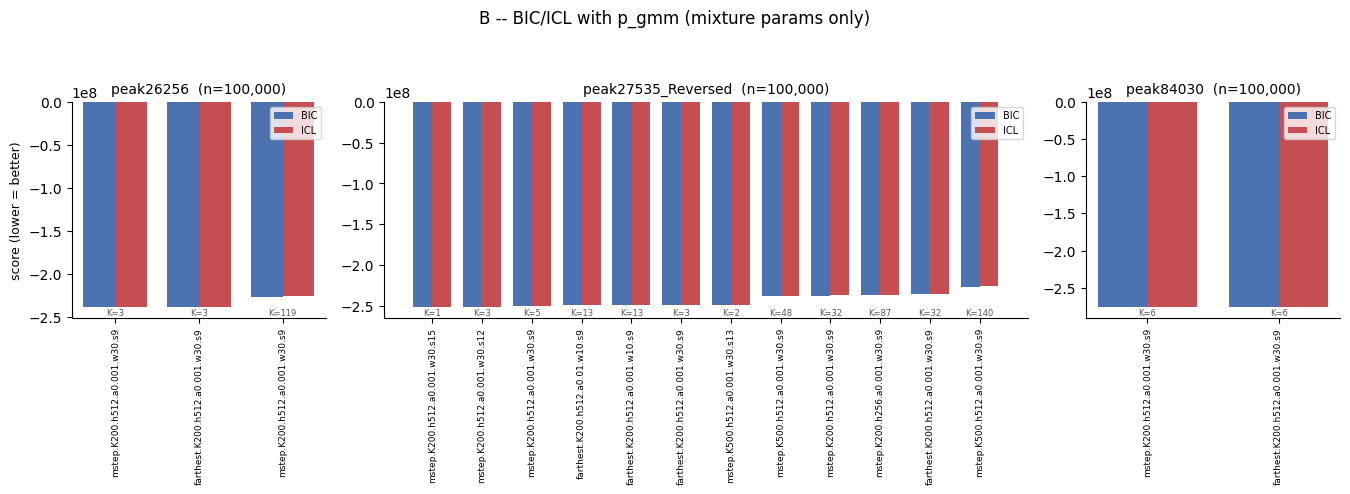

In [39]:
# B: penalize only the mixture params (VAE as a fixed feature extractor) -- same ELBO + responsibilities as A
plot_bic("BIC_gmm", "ICL_gmm", "B -- BIC/ICL with p_gmm (mixture params only)", "bic_icl_B_gmm.png")

saved -> /grid/koo/home/pmantill/projects/VBI/VAE_gmm/BIC_benchmark/functional_coherence.csv


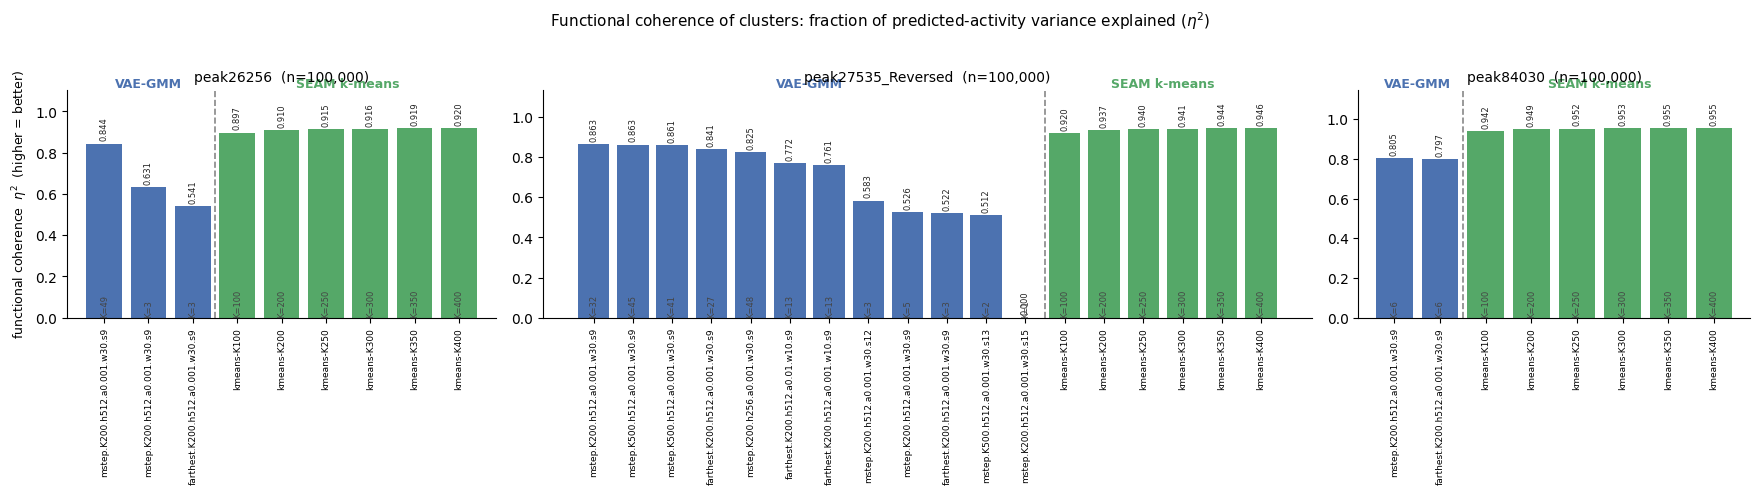

In [40]:
# ----- functional coherence: eta^2 of predicted activity across the hard cluster labels -----
# self-contained: reloads VAE checkpoints for their labels and reads SEAM cluster_labels directly.
_pred_cache = {}
def get_pred(peak, lib):
    if (peak, lib) not in _pred_cache:
        suffix = {"100k": "", "200k": "_200k"}[lib]
        with h5py.File(f"{SEAM_DIR}/ism{suffix}/{peak}.h5") as f:
            _pred_cache[(peak, lib)] = f["predictions"][:].astype(np.float64)
    return _pred_cache[(peak, lib)]

def eta2(labels, y):
    ybar = y.mean(); sst = ((y - ybar)**2).sum()
    ssw = 0.0
    for c in np.unique(labels):
        yc = y[labels == c]; ssw += ((yc - yc.mean())**2).sum()
    return float(1.0 - ssw / sst)

def vae_hard_labels(path):
    ck = torch.load(path, map_location=device, weights_only=False); hp = ck["hp"]
    peak, lib, J, K, hidden, a0 = hp["peak"], hp["lib"], hp["J"], hp["K"], hp["hidden"], hp["alpha0"]
    X_t = get_data(peak, lib); N = X_t.shape[0]
    model = VAE_GMM(X_t.shape[1], J, K, a0, hidden, np.ones(X_t.shape[1], np.float32)).to(device)
    model.load_state_dict(ck["state_dict"]); model.eval()
    hard = np.empty(N, dtype=np.int64)
    for i in range(0, N, 8192):
        _, g = model.elbo_and_gamma(X_t[i:i+8192]); hard[i:i+g.shape[0]] = g.argmax(1).cpu().numpy()
    return hard

lib_of = df.groupby("peak")["lib"].first().to_dict()
func_rows = []
# VAE configs (one row per config in df)
for r in df.itertuples():
    hard = vae_hard_labels(f"{RESULTS_DIR}/{r.file}")
    y = get_pred(r.peak, r.lib)
    func_rows.append(dict(peak=r.peak, method="VAE", label=r.model,
                          n_clusters=int(len(np.unique(hard))), eta2=eta2(hard, y)))
# SEAM k-means partitions (all available K per seq, same lib as the VAE runs)
for peak in sorted(lib_of):
    lib = lib_of[peak]; suffix = {"100k": "", "200k": "_200k"}[lib]
    y = get_pred(peak, lib)
    Ks = sorted(int(m.group(1)) for d in glob.glob(f"{SEAM_DIR}/foregrounds{suffix}_kmeans*")
                if (m := re.search(r"kmeans(\d+)$", d)) and os.path.isdir(f"{d}/{peak}"))
    for K in Ks:
        lab = np.load(f"{SEAM_DIR}/foregrounds{suffix}_kmeans{K}/{peak}/cluster_labels.npy")
        func_rows.append(dict(peak=peak, method="SEAM", label=f"kmeans-K{K}",
                              n_clusters=int(len(np.unique(lab))), eta2=eta2(lab, y)))

df_func = pd.DataFrame(func_rows)
df_func.to_csv(f"{OUT_DIR}/functional_coherence.csv", index=False)
print("saved ->", f"{OUT_DIR}/functional_coherence.csv")

# ----- plot: eta^2 per config, x = config (VAE block then SEAM block), one panel per seq -----
peaks = sorted(df_func["peak"].unique())
def _order(peak):
    v = df_func[(df_func.peak == peak) & (df_func.method == "VAE")].sort_values("eta2", ascending=False)
    s = df_func[(df_func.peak == peak) & (df_func.method == "SEAM")].sort_values("n_clusters")
    return pd.concat([v, s], ignore_index=True)
widths = [max(3.0, 0.42*len(_order(p)) + 1.0) for p in peaks]
fig, axes = plt.subplots(1, len(peaks), figsize=(sum(widths), 4.8),
                         squeeze=False, gridspec_kw={"width_ratios": widths})
cmap = {"VAE": "#4C72B0", "SEAM": "#55A868"}
for ci, peak in enumerate(peaks):
    a = axes[0][ci]; d = _order(peak); x = np.arange(len(d))
    a.bar(x, d["eta2"], color=[cmap[m] for m in d["method"]])
    a.set_ylim(0, max(d["eta2"].max(), 1e-6) * 1.20)                 # headroom for value labels
    for xi, val in zip(x, d["eta2"]):                               # actual value just above each bar
        a.annotate(f"{val:.3f}", (xi, val), ha="center", va="bottom", fontsize=6, rotation=90,
                   xytext=(0, 2), textcoords="offset points", color="#222")
    for xi, nc in zip(x, d["n_clusters"]):
        a.annotate(f"K={nc}", (xi, 0), ha="center", va="bottom", fontsize=6, color="#444", rotation=90)
    nb_vae = int((d["method"] == "VAE").sum())
    if 0 < nb_vae < len(d):
        a.axvline(nb_vae - 0.5, color="#888", ls="--", lw=1.2)
        top = a.get_ylim()[1]
        a.text((nb_vae-1)/2, top, "VAE-GMM", ha="center", va="bottom", fontsize=9, fontweight="bold", color="#4C72B0")
        a.text((nb_vae+len(d)-1)/2, top, "SEAM k-means", ha="center", va="bottom", fontsize=9, fontweight="bold", color="#55A868")
    a.set_xticks(x); a.set_xticklabels(d["label"], rotation=90, ha="center", fontsize=6.5)
    a.set_title(f"{peak}  (n={len(get_pred(peak, lib_of[peak])):,})", fontsize=10)
    a.spines[["top", "right"]].set_visible(False)                    # drop top/right spines
    if ci == 0:
        a.set_ylabel(r"functional coherence  $\eta^2$  (higher = better)", fontsize=9)
plt.suptitle(r"Functional coherence of clusters: fraction of predicted-activity variance explained ($\eta^2$)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/functional_coherence.png", dpi=150, bbox_inches="tight")
plt.show()

saved -> /grid/koo/home/pmantill/projects/VBI/VAE_gmm/BIC_benchmark/bic_icl_latent.csv
peak26256            J4 mstep.K200.h512.a0.001.w30.s9 K_alive=119  BIC_lat=5.0143e+05  ICL_lat=9.4548e+05
peak26256            J8 mstep.K200.h512.a0.001.w30.s9 K_alive=  3  BIC_lat=9.3731e+05  ICL_lat=9.7405e+05
peak26256            J8 farthest.K200.h512.a0.001.w30.s9 K_alive=  3  BIC_lat=1.0031e+06  ICL_lat=1.0519e+06
peak27535_Reversed   J2 mstep.K500.h512.a0.001.w30.s9 K_alive=140  BIC_lat=5.2335e+05  ICL_lat=8.3926e+05
peak27535_Reversed   J4 mstep.K200.h256.a0.001.w30.s9 K_alive= 87  BIC_lat=4.3487e+05  ICL_lat=6.7101e+05
peak27535_Reversed   J4 mstep.K500.h512.a0.001.w30.s9 K_alive= 48  BIC_lat=7.4449e+05  ICL_lat=8.5172e+05
peak27535_Reversed   J4 mstep.K200.h512.a0.001.w30.s9 K_alive= 32  BIC_lat=7.5168e+05  ICL_lat=8.5026e+05
peak27535_Reversed   J4 farthest.K200.h512.a0.001.w30.s9 K_alive= 32  BIC_lat=8.4093e+05  ICL_lat=9.5477e+05
peak27535_Reversed   J8 mstep.K200.h512.a0.001.w30.s15 K_al

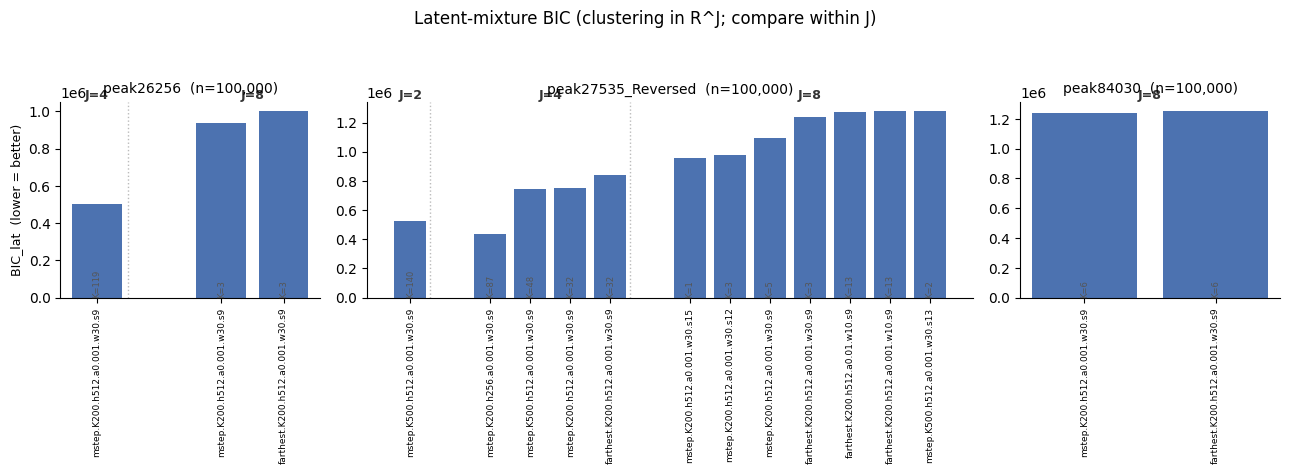

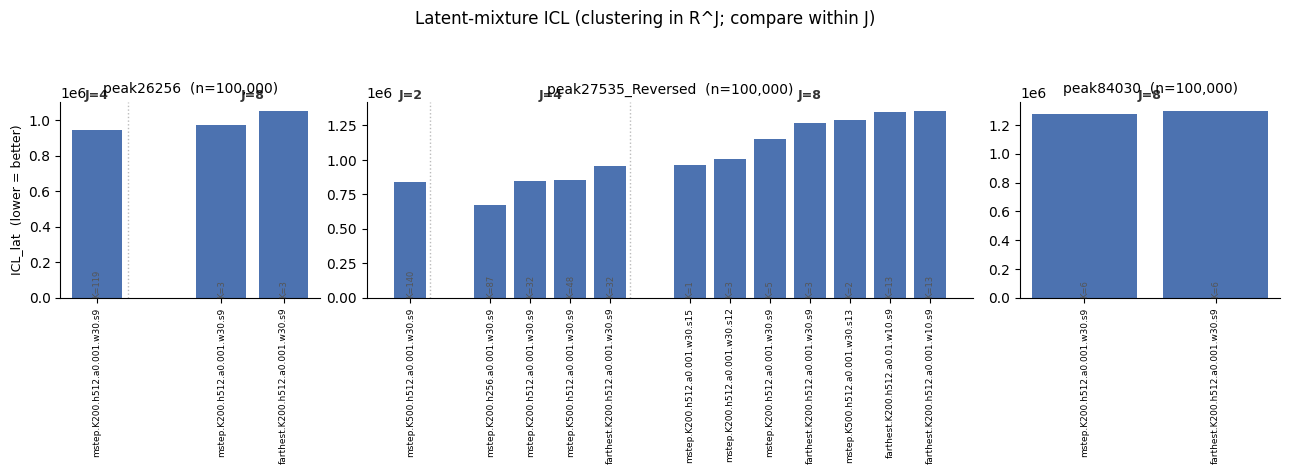

In [41]:
# ----- score the mixture in latent space R^J (clustering-sensitive) -----
# self-contained: reload each checkpoint, encode -> mu_z, evaluate the model's GMM (pi, mu_c, sigma_c) there.
log2pi = np.log(2 * np.pi)

def latent_mixture_score(path):
    ck = torch.load(path, map_location=device, weights_only=False); hp = ck["hp"]
    peak, lib, J, K, hidden, a0 = hp["peak"], hp["lib"], hp["J"], hp["K"], hp["hidden"], hp["alpha0"]
    warm, seed = hp.get("warmup_epochs"), hp.get("seed")
    X_t = get_data(peak, lib); N = X_t.shape[0]
    model = VAE_GMM(X_t.shape[1], J, K, a0, hidden, np.ones(X_t.shape[1], np.float32)).to(device)
    model.load_state_dict(ck["state_dict"]); model.eval()

    with torch.no_grad():
        alpha = model.alpha
        E_pi   = alpha / alpha.sum()                               # (K,) mixture weights
        log_pi = torch.log(E_pi.clamp_min(1e-300))                 # (K,)
        inv    = torch.exp(-model.log_var_c)                       # (K,J) precisions
        const  = -0.5 * (J * log2pi + model.log_var_c.sum(1)) + log_pi   # (K,) logN norm + log pi
        mu_inv = model.mu_c * inv; quad = (model.mu_c * mu_inv).sum(1)   # (K,) for expanded mahalanobis
        logL = EN = 0.0
        for i in range(0, N, 8192):
            mu_z, _ = model.encode(X_t[i:i+8192])                  # (b,J) fixed feature
            logjoint = const[None] - 0.5 * ((mu_z**2) @ inv.T - 2 * mu_z @ mu_inv.T + quad[None])  # (b,K)
            lm = torch.logsumexp(logjoint, 1); logL += float(lm.sum())
            r = (logjoint - lm[:, None]).exp()
            EN += float((-torch.where(r > 0, r * torch.log(r), torch.zeros_like(r))).sum())
        K_alive = int((E_pi.cpu().numpy() > 1.0 / N).sum())

    p_gmm = K_alive * (2 * J) + max(K_alive - 1, 0)
    lnN = np.log(N)
    init = init_label(os.path.basename(path))
    return dict(peak=peak, model=f"{init}.K{K}.h{hidden}.a{a0:g}.w{warm}.s{seed}", init=init,
                J=J, n=N, K_alive=K_alive, logL_lat=logL, EN_lat=EN, p_gmm=p_gmm,
                BIC_lat=-2*logL + p_gmm*lnN, ICL_lat=-2*logL + p_gmm*lnN + 2*EN)

df_lat = pd.DataFrame([latent_mixture_score(f"{RESULTS_DIR}/{r.file}") for r in df.itertuples()])
df_lat = df_lat.sort_values(["peak", "J", "BIC_lat"]).reset_index(drop=True)
df_lat.to_csv(f"{OUT_DIR}/bic_icl_latent.csv", index=False)
print("saved ->", f"{OUT_DIR}/bic_icl_latent.csv")
for r in df_lat.itertuples():
    print(f"{r.peak:20s} J{r.J} {r.model:28s} K_alive={r.K_alive:3d}  BIC_lat={r.BIC_lat:.4e}  ICL_lat={r.ICL_lat:.4e}")

# ----- two plots: latent-mixture BIC and ICL, per config, split by J (compare only within a J) -----
def plot_latent(metric, ttl, fname):
    peaks = sorted(df_lat["peak"].unique())
    widths = [max(3.0, 0.5*len(df_lat[df_lat["peak"] == p]) + 1.0) for p in peaks]
    fig, axes = plt.subplots(1, len(peaks), figsize=(sum(widths), 4.6),
                             squeeze=False, gridspec_kw={"width_ratios": widths})
    for ci, peak in enumerate(peaks):
        d = df_lat[df_lat["peak"] == peak].sort_values(["J", metric]).reset_index(drop=True)
        a = axes[0][ci]
        xs, cur, prevJ, bounds = [], 0.0, None, []
        for J in d["J"]:
            if prevJ is not None and J != prevJ:
                bounds.append(cur - 0.5); cur += 1.0
            xs.append(cur); cur += 1.0; prevJ = J
        x = np.array(xs)
        a.bar(x, d[metric], color="#4C72B0")
        for xi, ka in zip(x, d["K_alive"]):
            a.annotate(f"K={ka}", (xi, a.get_ylim()[0]), ha="center", va="bottom", fontsize=6, color="#555", rotation=90)
        for b in bounds:
            a.axvline(b, color="#bbb", ls=":", lw=1)
        top = a.get_ylim()[1]
        for J in sorted(d["J"].unique()):
            a.text(x[d["J"].values == J].mean(), top, f"J={J}", ha="center", va="bottom",
                   fontsize=9, fontweight="bold", color="#333")
        a.set_xticks(x); a.set_xticklabels(d["model"], rotation=90, ha="center", fontsize=6.5)
        a.set_title(f"{peak}  (n={int(d['n'].iloc[0]):,})", fontsize=10)
        a.spines[["top", "right"]].set_visible(False)
        if ci == 0:
            a.set_ylabel(f"{metric}  (lower = better)", fontsize=9)
    plt.suptitle(ttl, fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/{fname}", dpi=150, bbox_inches="tight")
    plt.show()

plot_latent("BIC_lat", "Latent-mixture BIC (clustering in R^J; compare within J)", "bic_latent.png")
plot_latent("ICL_lat", "Latent-mixture ICL (clustering in R^J; compare within J)", "icl_latent.png")